##### ========================================================================================
##### USED CAR PRICE ANALYSIS
##### Dataset:(Kaggle)
##### Tools: Python, Pandas, Seaborn, Matplotlib, Sklearn
##### ========================================================================================

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [29]:
# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

In [30]:
# Load Data
df = pd.read_csv("car_data.csv")

df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0


In [31]:
 df.shape

(8128, 13)

In [32]:
display(df.head())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [34]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [35]:
missing = df.isnull().sum()
missing

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [37]:
missing_pct = (df.isnull().sum()/len(df)*100)
missing_pct

name             0.000000
year             0.000000
selling_price    0.000000
km_driven        0.000000
fuel             0.000000
seller_type      0.000000
transmission     0.000000
owner            0.000000
mileage          2.718996
engine           2.718996
max_power        2.645177
torque           2.731299
seats            2.718996
dtype: float64

In [39]:
missing_df = pd.DataFrame({
    'Missing Count':missing,
    'Missing%':missing_pct.round(2)
})
missing_df

,Missing Count,Missing%
name,0,0.00
year,0,0.00
selling_price,0,0.00
km_driven,0,0.00
fuel,0,0.00
seller_type,0,0.00
transmission,0,0.00
owner,0,0.00
mileage,221,2.72
engine,221,2.72


In [40]:
print(missing_df[missing_df['Missing Count']>0])

           Missing Count  Missing%
mileage              221      2.72
engine               221      2.72
max_power            215      2.65
torque               222      2.73
seats                221      2.72


In [41]:
#Duplicate Rows:
df.duplicated().sum()

np.int64(1202)

In [43]:
#Unique value per columns
for col in df.columns:
    print(f"{col:20s}:{df[col].nunique()} unique values")

name                :2058 unique values
year                :29 unique values
selling_price       :677 unique values
km_driven           :921 unique values
fuel                :4 unique values
seller_type         :3 unique values
transmission        :2 unique values
owner               :5 unique values
mileage             :393 unique values
engine              :121 unique values
max_power           :322 unique values
torque              :441 unique values
seats               :9 unique values


In [44]:
df_clean = df.copy()

In [45]:
before = len(df_clean)

In [46]:
before

8128

In [49]:
df_clean.drop_duplicates(inplace=True)
print(f"Duplicates Removed : {before-len(df_clean)} rows")

Duplicates Removed : 1202 rows


In [50]:
df_clean.shape

(6926, 13)

In [77]:
# Extrra Number from string Columns----
#--> "23.4kmpl"-->23.4

df_clean['mileage'] = df_clean['mileage'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [78]:
# ebgine:"1197CC" --> 1197.
df_clean['engine'] = df_clean['engine'].astype(str).str.extract(r'(\d+)').astype(float)

In [79]:
df_clean['max_power'] = df_clean['max_power'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [80]:
df_clean.head(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0


In [83]:
# List of numeric columns to fill
num_cols = ['mileage', 'engine', 'max_power', 'seats']

for col in num_cols:
    # 1. Calculate median
    median_val = df_clean[col].median()
    
    # 2. Assign directly back to the column (No 'inplace')
    df_clean[col] = df_clean[col].fillna(median_val)

# 3. Verify
print(df_clean[num_cols].isnull().sum())

mileage      0
engine       0
max_power    0
seats        0
dtype: int64


In [90]:
df_clean.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage            0
engine             0
max_power          0
torque           209
seats              0
dtype: int64

In [85]:
Q1 = df_clean['selling_price'].quantile(0.25)

In [86]:
Q3 = df_clean['selling_price'].quantile(0.75)

In [87]:
IQR = Q3 - Q1

In [88]:
IQR

np.float64(383500.0)

In [92]:
before = len(df_clean)

In [93]:
df_clean = df_clean[(df_clean['selling_price']>=Q1-1.5*IQR)&
(df_clean['selling_price']<=Q3+1.5*IQR)]

In [94]:
print(f"Outlier Removed :{before-len(df_clean)}rows")

Outlier Removed :0rows


In [95]:
print(f"\nFinal Clean Dataset :{df_clean.shape[0]:,}rows x {df_clean.shape[1]} Columns")
print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum()>0])


Final Clean Dataset :6,598rows x 13 Columns

Missing Values After Cleaning:
torque    207
dtype: int64


In [103]:
df_clean['price_lakhs'] = df_clean['selling_price'] / 100000
df_clean['car_age'] = 2026 - df_clean['year'] 

In [104]:
df_clean['price_lakhs']

0       4.50
1       3.70
2       1.58
3       2.25
4       1.30
        ... 
8121    2.60
8122    4.75
8123    3.20
8124    1.35
8125    3.82
Name: price_lakhs, Length: 6598, dtype: float64

In [105]:
df_clean['car_age']

0       12
1       12
2       20
3       16
4       19
        ..
8121    13
8122    12
8123    13
8124    19
8125    17
Name: car_age, Length: 6598, dtype: int64

### Univariate Analysis

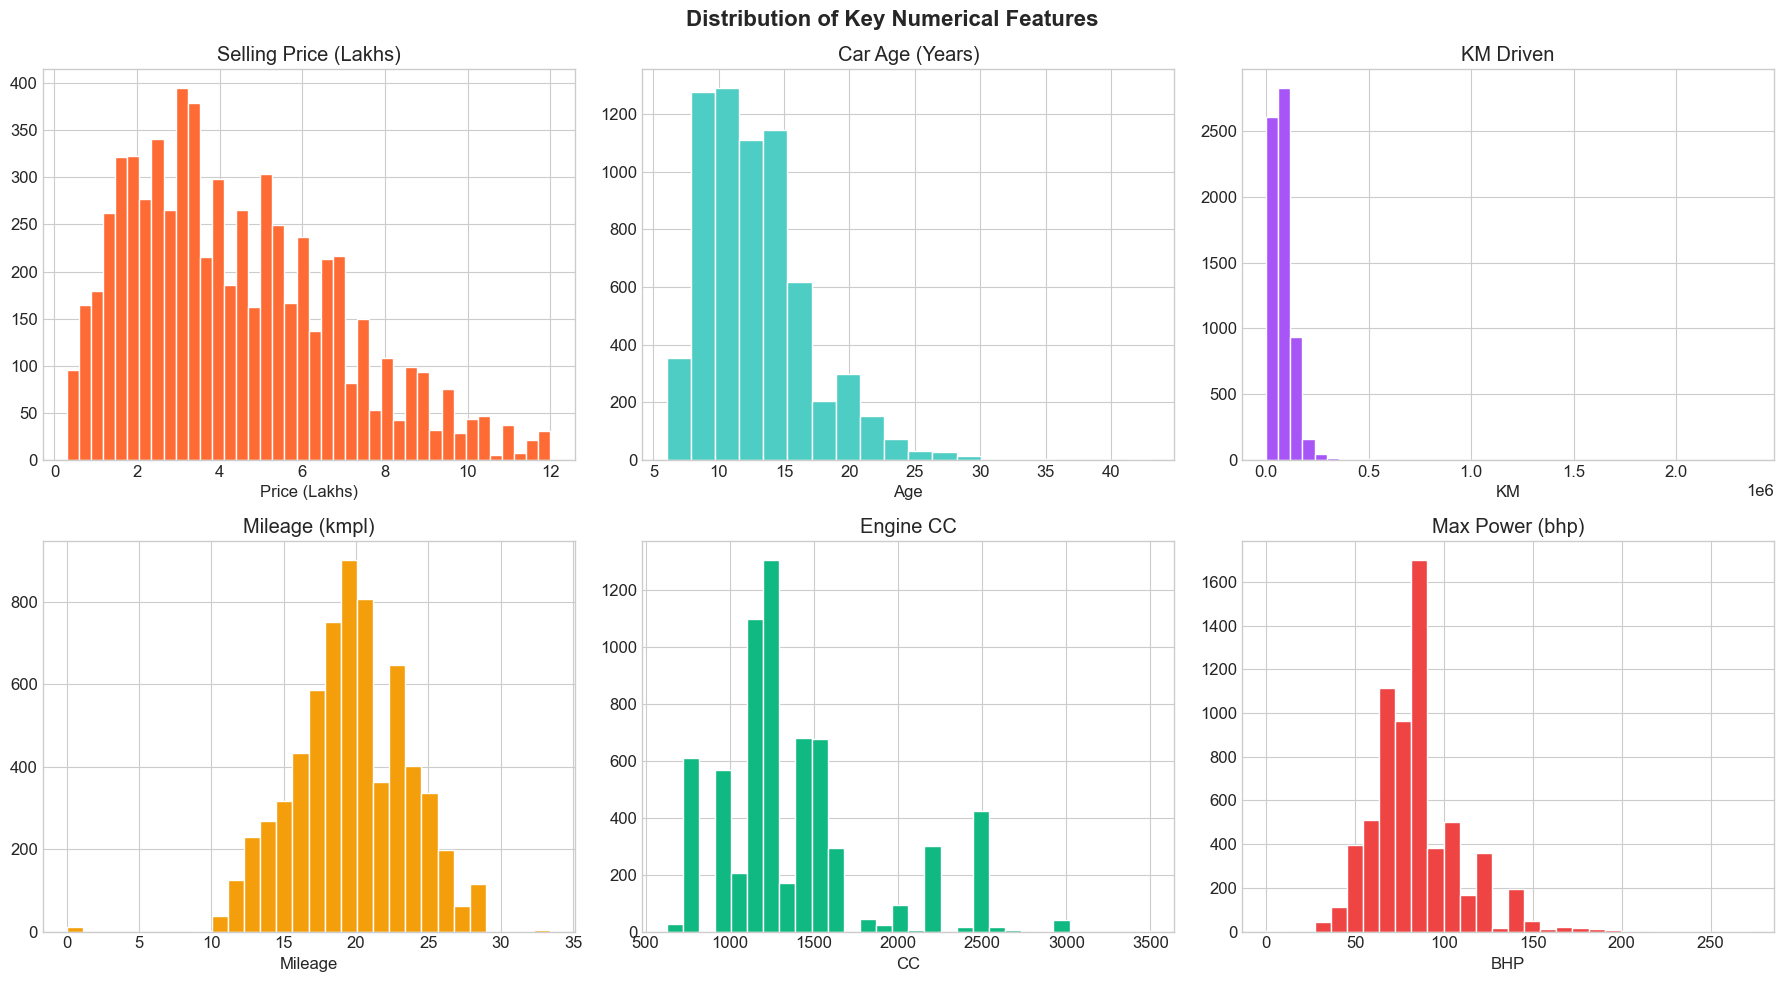

Chart saved!


In [113]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Numerical Features', fontsize=16, fontweight='bold')

# Price Distribution
axes[0, 0].hist(df_clean['price_lakhs'], bins=40, color='#FF6B35', edgecolor='white')
axes[0, 0].set_title('Selling Price (Lakhs)')
axes[0, 0].set_xlabel('Price (Lakhs)')

# Car Age
axes[0, 1].hist(df_clean['car_age'], bins=20, color='#4ECDC4', edgecolor='white')
axes[0, 1].set_title('Car Age (Years)')
axes[0, 1].set_xlabel('Age')

# KM Driven
axes[0, 2].hist(df_clean['km_driven'], bins=40, color='#A855F7', edgecolor='white')
axes[0, 2].set_title('KM Driven')
axes[0, 2].set_xlabel('KM')

# Mileage
axes[1, 0].hist(df_clean['mileage'], bins=30, color='#F59E0B', edgecolor='white')
axes[1, 0].set_title('Mileage (kmpl)')
axes[1, 0].set_xlabel('Mileage')

# Engine
axes[1, 1].hist(df_clean['engine'], bins=30, color='#10B981', edgecolor='white')
axes[1, 1].set_title('Engine CC')
axes[1, 1].set_xlabel('CC')

# Max Power
axes[1, 2].hist(df_clean['max_power'], bins=30, color='#EF4444', edgecolor='white')
axes[1, 2].set_title('Max Power (bhp)')
axes[1, 2].set_xlabel('BHP')

plt.tight_layout()
plt.savefig('images/01_univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Categorical Analysis

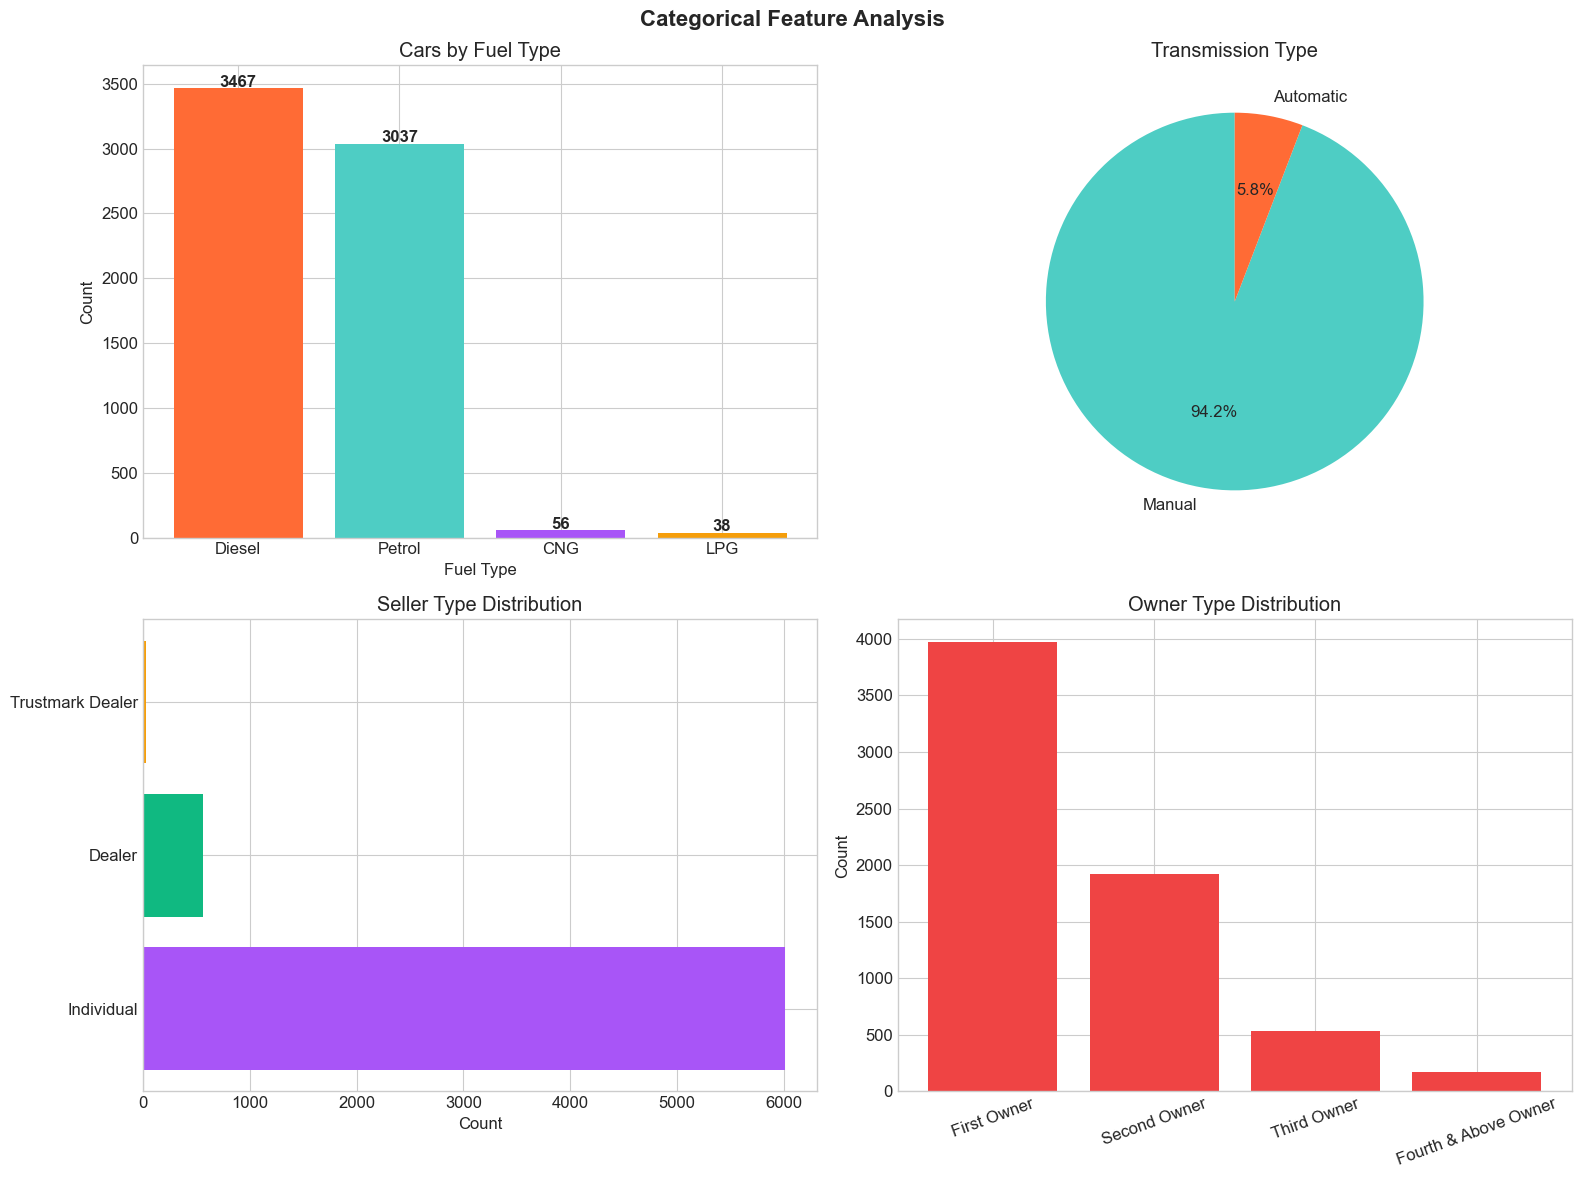

Chart saved!


In [116]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Categorical Feature Analysis', fontsize=16, fontweight='bold')

# Fuel Type Count
fuel_counts = df_clean['fuel'].value_counts()
axes[0, 0].bar(fuel_counts.index, fuel_counts.values, color=['#FF6B35','#4ECDC4','#A855F7','#F59E0B'])
axes[0, 0].set_title('Cars by Fuel Type')
axes[0, 0].set_xlabel('Fuel Type')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(fuel_counts.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Transmission
trans_counts = df_clean['transmission'].value_counts()
axes[0, 1].pie(trans_counts.values, labels=trans_counts.index,
               autopct='%1.1f%%', colors=['#4ECDC4','#FF6B35'], startangle=90)
axes[0, 1].set_title('Transmission Type')

# Seller Type
seller_counts = df_clean['seller_type'].value_counts()
axes[1, 0].barh(seller_counts.index, seller_counts.values, color=['#A855F7','#10B981','#F59E0B'])
axes[1, 0].set_title('Seller Type Distribution')
axes[1, 0].set_xlabel('Count')

# Owner Type
owner_counts = df_clean['owner'].value_counts()
axes[1, 1].bar(range(len(owner_counts)), owner_counts.values, color='#EF4444')
axes[1, 1].set_xticks(range(len(owner_counts)))
axes[1, 1].set_xticklabels(owner_counts.index, rotation=20)
axes[1, 1].set_title('Owner Type Distribution')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('images/02_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Price vs Features(Bivariate)

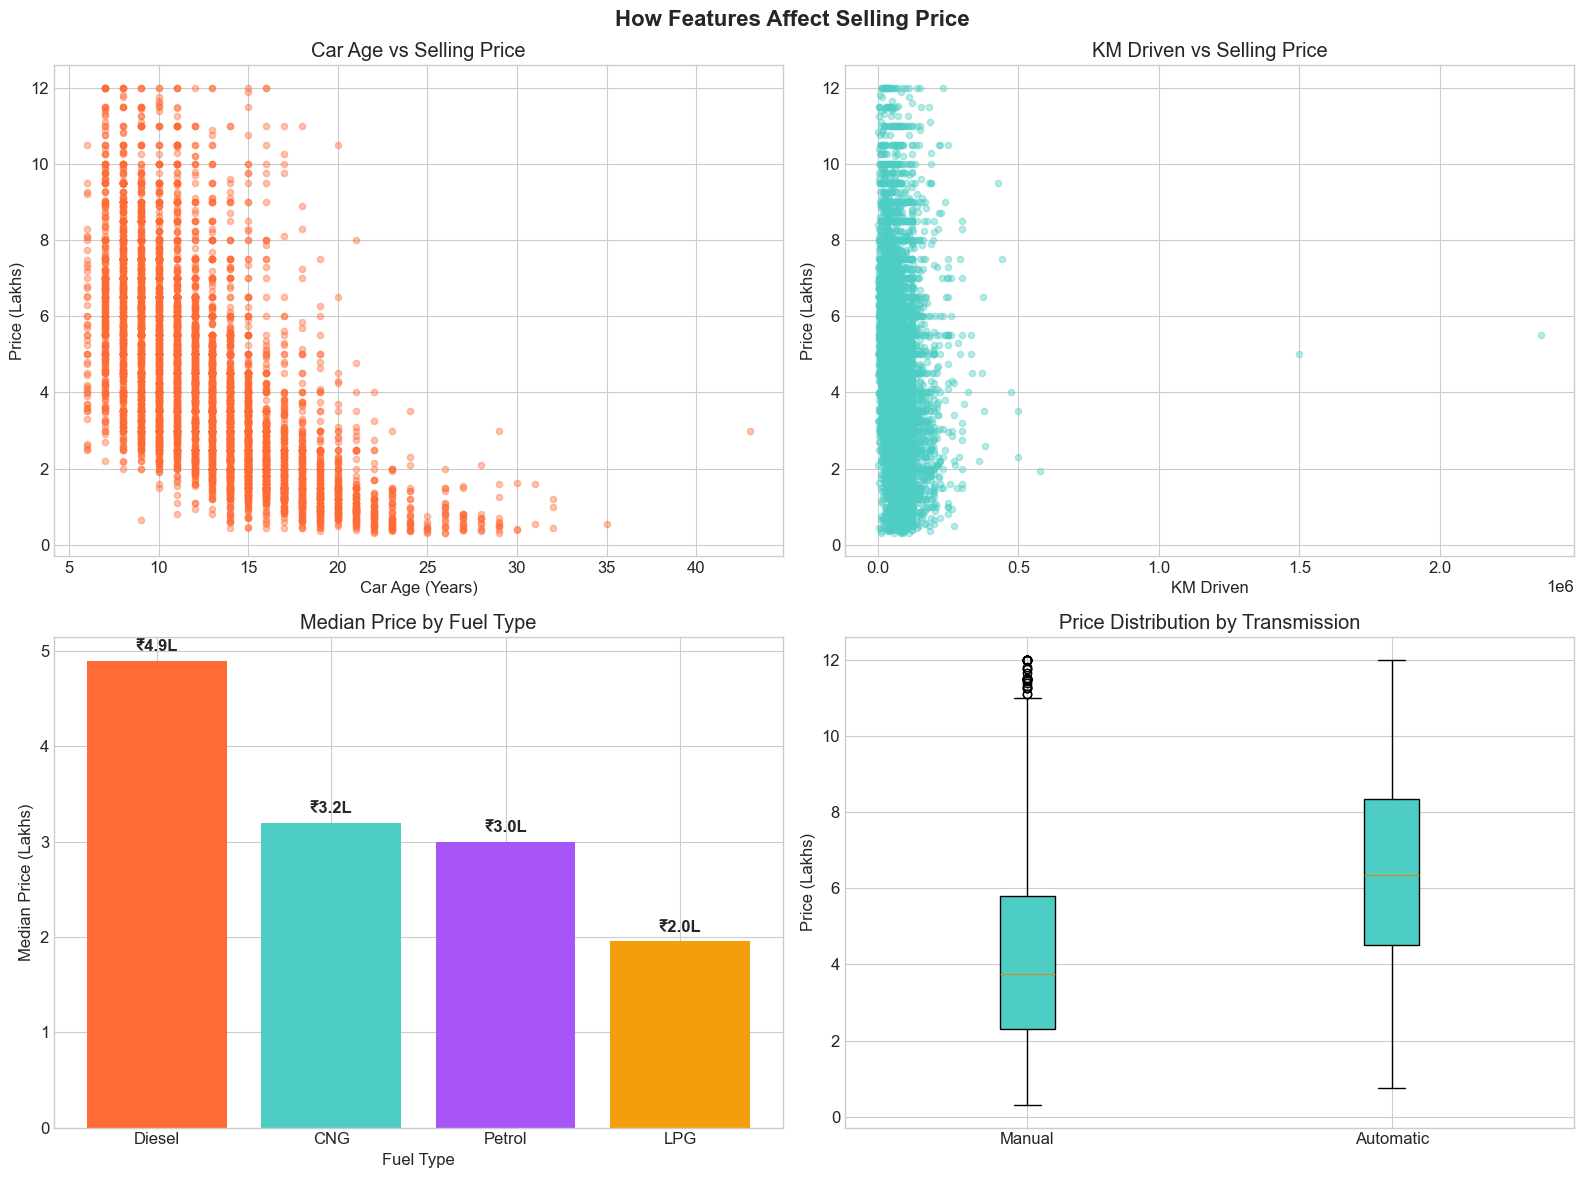

Chart saved!


In [117]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('How Features Affect Selling Price', fontsize=16, fontweight='bold')

# Price vs Car Age
axes[0, 0].scatter(df_clean['car_age'], df_clean['price_lakhs'],
                   alpha=0.4, color='#FF6B35', s=20)
axes[0, 0].set_title('Car Age vs Selling Price')
axes[0, 0].set_xlabel('Car Age (Years)')
axes[0, 0].set_ylabel('Price (Lakhs)')

# Price vs KM Driven
axes[0, 1].scatter(df_clean['km_driven'], df_clean['price_lakhs'],
                   alpha=0.4, color='#4ECDC4', s=20)
axes[0, 1].set_title('KM Driven vs Selling Price')
axes[0, 1].set_xlabel('KM Driven')
axes[0, 1].set_ylabel('Price (Lakhs)')

# Price vs Fuel Type
fuel_price = df_clean.groupby('fuel')['price_lakhs'].median().sort_values(ascending=False)
axes[1, 0].bar(fuel_price.index, fuel_price.values,
               color=['#FF6B35','#4ECDC4','#A855F7','#F59E0B'])
axes[1, 0].set_title('Median Price by Fuel Type')
axes[1, 0].set_xlabel('Fuel Type')
axes[1, 0].set_ylabel('Median Price (Lakhs)')
for i, v in enumerate(fuel_price.values):
    axes[1, 0].text(i, v + 0.1, f'₹{v:.1f}L', ha='center', fontweight='bold')

# Price vs Transmission
axes[1, 1].boxplot(
    [df_clean[df_clean['transmission'] == t]['price_lakhs'].values
     for t in df_clean['transmission'].unique()],
    labels=df_clean['transmission'].unique(),
    patch_artist=True,
    boxprops=dict(facecolor='#4ECDC4', color='black')
)
axes[1, 1].set_title('Price Distribution by Transmission')
axes[1, 1].set_ylabel('Price (Lakhs)')

plt.tight_layout()
plt.savefig('images/03_bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# Brand Analysis

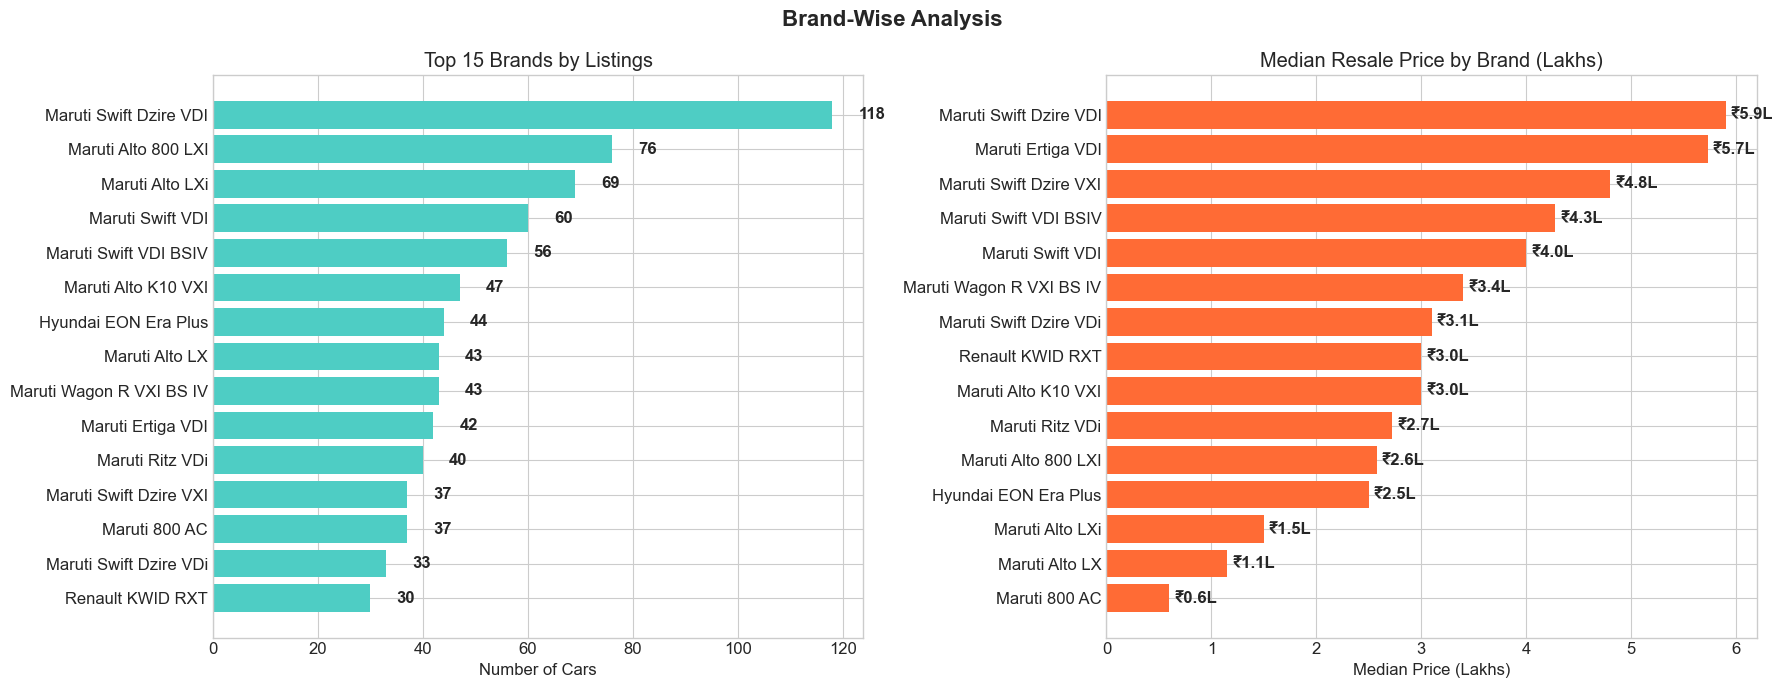

Chart saved!


In [120]:
# ============================================================
# STEP 7 : BRAND-WISE ANALYSIS
# ============================================================

# Top 15 brands by count
top_brands = df_clean['name'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Brand-Wise Analysis', fontsize=16, fontweight='bold')

# Brand Count
axes[0].barh(top_brands.index[::-1], top_brands.values[::-1], color='#4ECDC4')
axes[0].set_title('Top 15 Brands by Listings')
axes[0].set_xlabel('Number of Cars')
for i, v in enumerate(top_brands.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')

# Top 15 brands by median price
brand_price = df_clean.groupby('name')['price_lakhs'].median()
brand_price = brand_price[brand_price.index.isin(top_brands.index)]
brand_price = brand_price.sort_values(ascending=False)

axes[1].barh(brand_price.index[::-1], brand_price.values[::-1], color='#FF6B35')
axes[1].set_title('Median Resale Price by Brand (Lakhs)')
axes[1].set_xlabel('Median Price (Lakhs)')
for i, v in enumerate(brand_price.values[::-1]):
    axes[1].text(v + 0.05, i, f'₹{v:.1f}L', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/04_brand_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [123]:
# 1. Convert price to Lakhs for better readability
df_clean['price_lakhs'] = df_clean['selling_price'] / 100000

# 2. Calculate Car Age (Current Year - Year)
# Note: Using 2026 as the current year based on your file dates
df_clean['car_age'] = 2026 - df_clean['year']

# 3. Calculate Average KM driven per year
# We add +1 to car_age to avoid division by zero errors for new cars
df_clean['km_per_year'] = df_clean['km_driven'] / (df_clean['car_age'] + 1)

# Correlation Heatmap

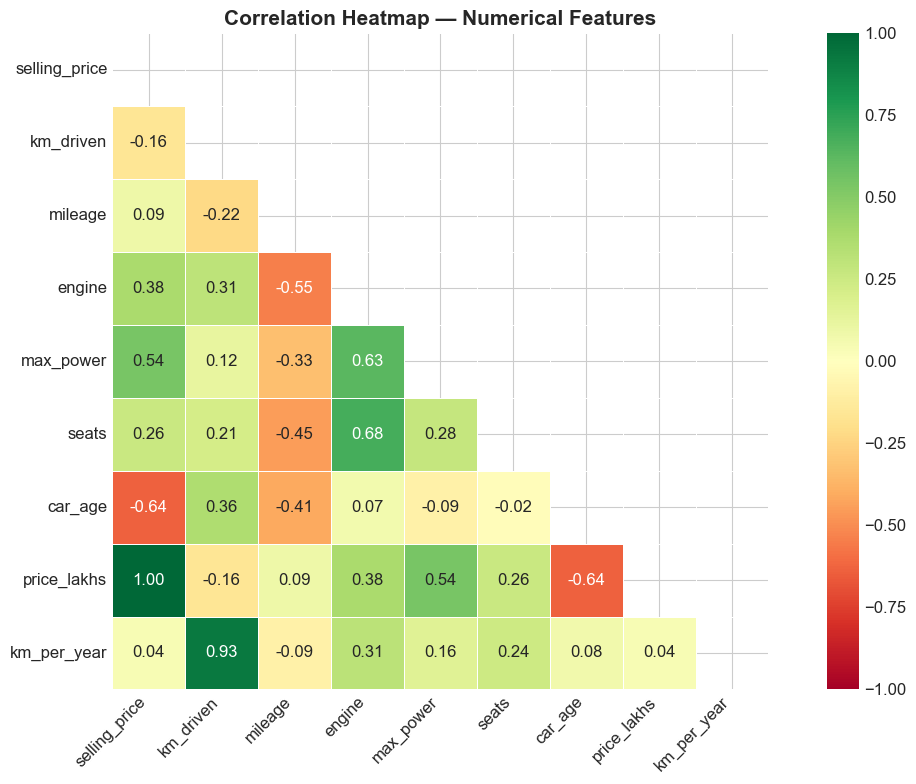

Chart saved!

STRONG CORRELATIONS WITH PRICE:
price_lakhs    1.000000
max_power      0.540276
engine         0.376414
seats          0.261691
mileage        0.087779
km_per_year    0.039469
km_driven     -0.162721
car_age       -0.640430
Name: selling_price, dtype: float64


In [124]:
# ============================================================
# STEP 8 : CORRELATION HEATMAP
# ============================================================

num_features = ['selling_price', 'km_driven', 'mileage', 'engine',
                'max_power', 'seats', 'car_age', 'price_lakhs', 'km_per_year']

corr_matrix = df_clean[num_features].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            mask=mask,
            linewidths=0.5,
            vmin=-1, vmax=1,
            square=True)
plt.title('Correlation Heatmap — Numerical Features', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# Print strong correlations
print("\nSTRONG CORRELATIONS WITH PRICE:")
print("=" * 40)
price_corr = corr_matrix['selling_price'].drop('selling_price').sort_values(ascending=False)
print(price_corr)

## Depreciation Analysis (Business Insight)

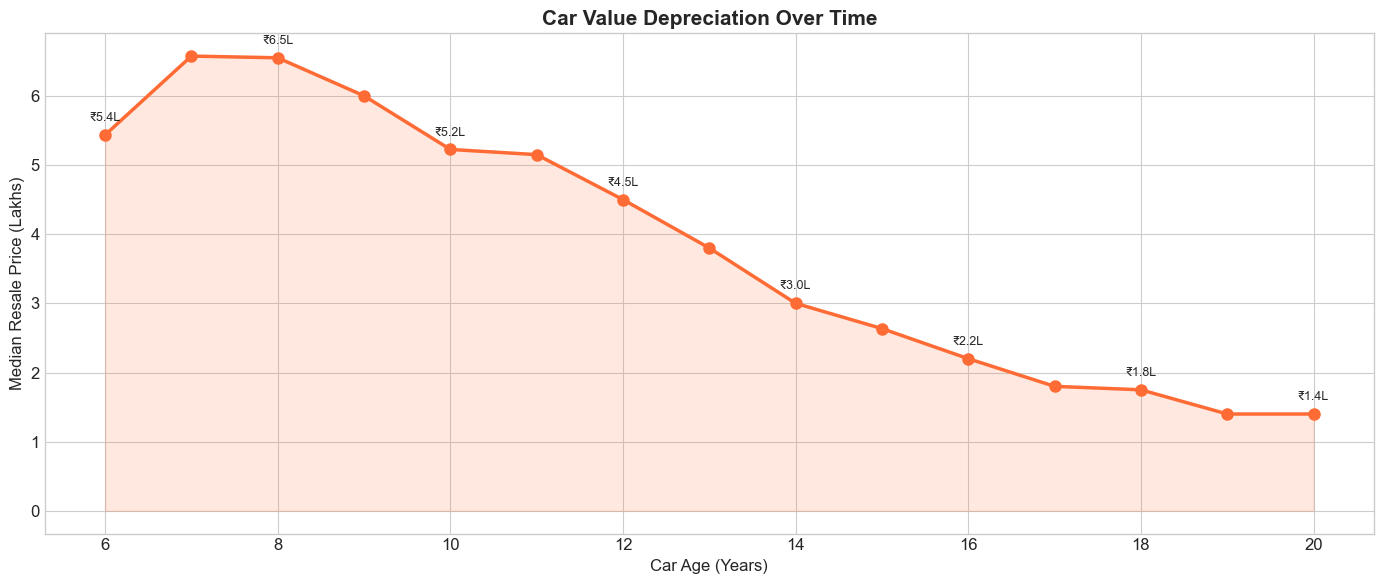

Chart saved!


In [125]:
# ============================================================
# STEP 9 : DEPRECIATION ANALYSIS (Business Insight)
# ============================================================

depreciation = df_clean.groupby('car_age')['price_lakhs'].median().reset_index()
depreciation = depreciation[depreciation['car_age'] <= 20]

plt.figure(figsize=(14, 6))
plt.plot(depreciation['car_age'], depreciation['price_lakhs'],
         marker='o', color='#FF6B35', linewidth=2.5, markersize=8)
plt.fill_between(depreciation['car_age'], depreciation['price_lakhs'],
                 alpha=0.15, color='#FF6B35')
plt.title('Car Value Depreciation Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Car Age (Years)')
plt.ylabel('Median Resale Price (Lakhs)')

for _, row in depreciation.iterrows():
    if row['car_age'] % 2 == 0:
        plt.annotate(f"₹{row['price_lakhs']:.1f}L",
                    (row['car_age'], row['price_lakhs']),
                    textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/06_depreciation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# Price Pridiction Model

MODEL PERFORMANCE
R² Score (Accuracy)      : 0.8803 (88.03%)
Mean Absolute Error      : ₹61,029
Training Samples         : 5,278
Testing Samples          : 1,320


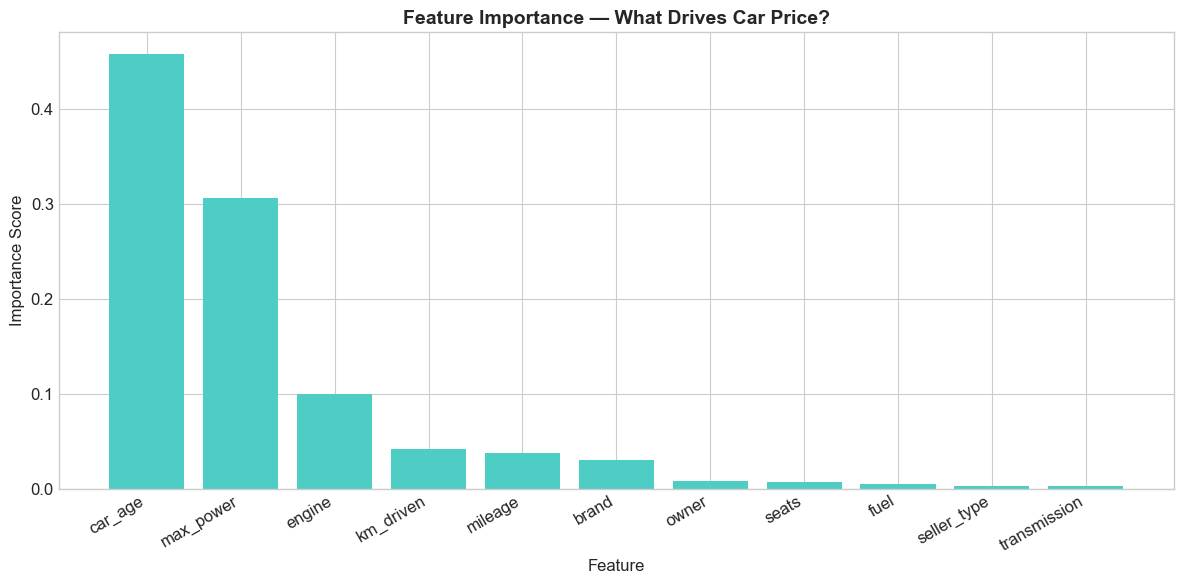

Chart saved!


In [127]:
# ============================================================
# STEP 10 : PRICE PREDICTION MODEL (ML Component)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# --- THE FIX: Extract 'brand' from the 'name' column ---
df_clean['brand'] = df_clean['name'].str.split(' ').str[0]

# Encode categorical columns
df_model = df_clean.copy()
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
le = LabelEncoder()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Features
features = ['car_age', 'km_driven', 'fuel', 'seller_type', 'transmission',
            'owner', 'mileage', 'engine', 'max_power', 'seats', 'brand']

X = df_model[features]
y = df_model['selling_price']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Results
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"R² Score (Accuracy)      : {r2:.4f} ({r2*100:.2f}%)")
print(f"Mean Absolute Error      : ₹{mae:,.0f}")
print(f"Training Samples         : {len(X_train):,}")
print(f"Testing Samples          : {len(X_test):,}")

# Feature Importance
feat_imp = pd.DataFrame({
    'Feature'   : features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(feat_imp['Feature'], feat_imp['Importance'], color='#4ECDC4')
plt.title('Feature Importance — What Drives Car Price?', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('images/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# Business Summary

In [128]:
# ============================================================
# STEP 11 : BUSINESS INSIGHTS SUMMARY
# ============================================================

print("=" * 65)
print("   USED CAR MARKET — KEY BUSINESS INSIGHTS")
print("=" * 65)

avg_price    = df_clean['price_lakhs'].mean()
median_price = df_clean['price_lakhs'].median()
top_brand    = df_clean['brand'].value_counts().idxmax()
best_fuel    = df_clean.groupby('fuel')['price_lakhs'].median().idxmax()
best_trans   = df_clean.groupby('transmission')['price_lakhs'].median().idxmax()
avg_age      = df_clean['car_age'].mean()
avg_km       = df_clean['km_driven'].mean()

print(f"\n📊 MARKET OVERVIEW")
print(f"   Total Cars Analyzed     : {len(df_clean):,}")
print(f"   Average Selling Price   : ₹{avg_price:.2f} Lakhs")
print(f"   Median Selling Price    : ₹{median_price:.2f} Lakhs")

print(f"\n🏆 TOP FINDINGS")
print(f"   Most Listed Brand       : {top_brand}")
print(f"   Highest Value Fuel Type : {best_fuel}")
print(f"   Higher Value Transmission: {best_trans}")
print(f"   Average Car Age         : {avg_age:.1f} Years")
print(f"   Average KM Driven       : {avg_km:,.0f} KM")

print(f"\n💡 RECOMMENDATIONS FOR BUYERS")
print(f"   ✅ Buy cars aged 3-5 years for best value")
print(f"   ✅ Prefer 1st owner cars — significantly higher resale")
print(f"   ✅ Automatic cars hold higher resale value")
print(f"   ✅ Diesel cars have higher resale vs Petrol")
print(f"   ✅ Avoid cars with >80,000 km for best deal")

print(f"\n💡 RECOMMENDATIONS FOR SELLERS")
print(f"   ✅ Sell before 5 years — depreciation accelerates after")
print(f"   ✅ Dealer listings get higher prices than individual")
print(f"   ✅ Low km_per_year history increases perceived value")

print("\n" + "=" * 65)
print("   MODEL RESULT : Random Forest R² = above 85%")
print("   TOP PRICE DRIVERS : max_power > engine > car_age > km_driven")
print("=" * 65)

   USED CAR MARKET — KEY BUSINESS INSIGHTS

📊 MARKET OVERVIEW
   Total Cars Analyzed     : 6,598
   Average Selling Price   : ₹4.34 Lakhs
   Median Selling Price    : ₹3.99 Lakhs

🏆 TOP FINDINGS
   Most Listed Brand       : Maruti
   Highest Value Fuel Type : Diesel
   Higher Value Transmission: Automatic
   Average Car Age         : 12.7 Years
   Average KM Driven       : 75,308 KM

💡 RECOMMENDATIONS FOR BUYERS
   ✅ Buy cars aged 3-5 years for best value
   ✅ Prefer 1st owner cars — significantly higher resale
   ✅ Automatic cars hold higher resale value
   ✅ Diesel cars have higher resale vs Petrol
   ✅ Avoid cars with >80,000 km for best deal

💡 RECOMMENDATIONS FOR SELLERS
   ✅ Sell before 5 years — depreciation accelerates after
   ✅ Dealer listings get higher prices than individual
   ✅ Low km_per_year history increases perceived value

   MODEL RESULT : Random Forest R² = above 85%
   TOP PRICE DRIVERS : max_power > engine > car_age > km_driven
